# Problem Description

Supermarket chains in Ecuador operate across dozens of cities and product categories, making demand forecasting a critical operational challenge. Accurate sales predictions help optimize inventory, reduce waste, and improve customer satisfaction.

This project forecasts **daily sales for 33 product families across 54 Favorita stores** over a multi-year period. The dataset combines transactional data with external signals — oil prices (Ecuador is an oil-dependent economy), national and regional holidays, promotions, and store metadata.

The project is structured as follows:
1. **Data loading and merging** — combine five CSV files into a single panel dataset.
2. **Exploratory Data Analysis** — understand sales patterns by store, product, and time.
3. **Panel Data Analysis** — quantify fixed effects using PanelOLS.
4. **Feature Engineering** — temporal features, lags, rolling averages, earthquake flag.
5. **Modelling** — Baseline ARIMA, XGBoost/LightGBM, and LSTM.
6. **Results & Conclusions** — business insights, explainability, and GitHub publication.

> **Target variable:** `sales` (total daily sales per store–family pair), transformed as `log(1 + sales)` to match the RMSLE evaluation metric.

In [686]:
import pandas as pd 
import numpy as np
import random
import matplotlib.pyplot as plt 
import matplotlib
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Libraries

Standard data science stack: `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualisation. Additional libraries will be imported in later sessions as needed.

In [291]:
seed = 123 
np.random.seed(seed)
random.seed(seed)

# Data

The dataset is sourced from the [Kaggle Store Sales — Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting) competition. It is split across five CSV files that are merged into a single panel dataset:

| File | Description |
|------|-------------|
| `stores_sales.csv` | Main dataset: daily sales per store and product family (2013–2017). Originally named `train.csv` in the competition. |
| `stores.csv` | Store metadata: city, state, type, and cluster |
| `transactions.csv` | Daily transaction counts per store |
| `oil.csv` | Daily oil price (WTI crude) — missing on weekends and public holidays |
| `holidays_events.csv` | National, regional, and local holidays with transfer metadata |

> **Note on evaluation:** The competition also provides `test.csv` and `sample_submission.csv`, but these are excluded here. `test.csv` does not contain the target variable `sales` — ground truth is held by Kaggle and only evaluated upon submission. Since we are not submitting to the competition, we renamed `train.csv` to `stores_sales.csv` and use a temporal hold-out of the last 15 days as our local validation set, replicating the same forecasting window.

In [292]:
holidays_events = pd.read_csv('data/holidays_events.csv')
oli = pd.read_csv('data/oil.csv')
stores = pd.read_csv('data/stores.csv')
transactions = pd.read_csv('data/transactions.csv')
stores_sales = pd.read_csv('data/stores_sales.csv')

In [293]:
holidays_events.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


A single date can appear multiple times in `holidays_events` — for example when a day is simultaneously a national and a local holiday. Merging without aggregating first would duplicate every sales row for that date, inflating the dataset artificially. The following confirms how many dates have more than one entry:

In [294]:
counts=holidays_events.groupby('date').agg({'date': 'count'})

counts[counts['date']>1]

,date
date,
2012-06-25,3
2012-07-03,2
2012-12-22,2
2012-12-24,2
2012-12-31,2
2013-05-12,2
2013-06-25,3
2013-07-03,2
2013-12-22,2


The `holidays_events` table has a non-trivial structure. A single date can appear multiple times — once per locale level (National, Regional, Local). The `transferred` column indicates that the official holiday was moved to another date by the government; transferred days behave like normal working days and should not be treated as holidays.

To avoid row duplication during the merge, we aggregate by date and create binary flags for each holiday type and locale level.

In [295]:
holidays_events['is_national'] = holidays_events['locale'] == 'National'
holidays_events['is_regional'] = holidays_events['locale'] == 'Regional'
holidays_events['is_local'] = holidays_events['locale'] == 'Local'
holidays_events['is_holiday'] = holidays_events['type'] == 'Holiday'
holidays_events['is_transfer'] = holidays_events['type'] == 'Transfer'
holidays_events['is_event'] = holidays_events['type'] == 'Event'
holidays_events['is_additional'] = holidays_events['type'] == 'Additional'
holidays_events['is_bridge'] = holidays_events['type'] == 'Bridge'


In [296]:
holidays_events=holidays_events.groupby('date').agg({'is_national': 'any', 'is_regional': 'any', 'is_local': 'any', 'is_holiday': 'any', 'is_transfer': 'any', 'is_event': 'any', 'is_additional': 'any', 'is_bridge': 'any'})

In [297]:
holidays_events.shape

(312, 8)

312 unique dates carry at least one holiday flag. The remaining dates in the training period (2013–2017) have no holiday record and will receive `False` for all flags after the left join.

In [298]:
oli.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


The oil price series (`dcoilwtico`) has missing values on weekends and public holidays — financial markets do not trade on those days. These gaps will be filled using **forward fill** after the merge, propagating the last known price forward. Any remaining nulls at the very start of the series are covered with **backward fill**.

In [299]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [300]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [301]:
stores_sales.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [302]:
stores_sales.shape

(3000888, 6)

## Dataset Construction

All files are merged into a single panel dataset using `stores_sales` (the training data) as the base. Each merge uses a **left join** to preserve all 3 million rows:

- `stores`: joins on `store_nbr` — adds city, state, store type, and cluster.
- `transactions`: joins on `store_nbr + date` — adds daily transaction counts.
- `oil`: joins on `date` — adds daily oil price (WTI crude).
- `holidays_events`: joins on `date` — adds the binary holiday flags created above.

In [303]:
stores_sales=stores_sales.merge(stores, left_on="store_nbr", right_on="store_nbr", how="left")
stores_sales=stores_sales.merge(transactions, left_on=["store_nbr", "date"], right_on=["store_nbr", "date"], how="left")
stores_sales=stores_sales.merge(oli, left_on="date", right_on="date", how="left")
stores_sales=stores_sales.merge(holidays_events, left_on="date", right_on="date", how="left")


In [304]:
stores_sales.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,is_national,is_regional,is_local,is_holiday,is_transfer,is_event,is_additional,is_bridge
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False


In [305]:
stores_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 20 columns):
 #   Column         Dtype  
---  ------         -----  
 0   id             int64  
 1   date           str    
 2   store_nbr      int64  
 3   family         str    
 4   sales          float64
 5   onpromotion    int64  
 6   city           str    
 7   state          str    
 8   type           str    
 9   cluster        int64  
 10  transactions   float64
 11  dcoilwtico     float64
 12  is_national    object 
 13  is_regional    object 
 14  is_local       object 
 15  is_holiday     object 
 16  is_transfer    object 
 17  is_event       object 
 18  is_additional  object 
 19  is_bridge      object 
dtypes: float64(3), int64(4), object(8), str(5)
memory usage: 457.9+ MB


In [306]:
stores_sales['date'] = pd.to_datetime(stores_sales['date'])

In [307]:
stores_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 20 columns):
 #   Column         Dtype         
---  ------         -----         
 0   id             int64         
 1   date           datetime64[us]
 2   store_nbr      int64         
 3   family         str           
 4   sales          float64       
 5   onpromotion    int64         
 6   city           str           
 7   state          str           
 8   type           str           
 9   cluster        int64         
 10  transactions   float64       
 11  dcoilwtico     float64       
 12  is_national    object        
 13  is_regional    object        
 14  is_local       object        
 15  is_holiday     object        
 16  is_transfer    object        
 17  is_event       object        
 18  is_additional  object        
 19  is_bridge      object        
dtypes: datetime64[us](1), float64(3), int64(4), object(8), str(4)
memory usage: 457.9+ MB


## Missing Value Treatment

After merging, three groups of columns contain nulls:

- **`transactions`** (245,784 nulls): store–date combinations with no transaction record had no activity — filled with `0`.
- **`dcoilwtico`** (928,422 nulls): weekends and holidays have no market price — filled with `ffill`, then `bfill` to cover the opening dates of the series.
- **`is_*` flags** (~2.5M nulls each): dates not in `holidays_events` are non-holiday days — filled with `False`, then cast to `bool` to reduce memory from 457 MB to 320 MB.

In [308]:
stores_sales.isnull().sum()

id                     0
date                   0
store_nbr              0
family                 0
sales                  0
onpromotion            0
city                   0
state                  0
type                   0
cluster                0
transactions      245784
dcoilwtico        928422
is_national      2551824
is_regional      2551824
is_local         2551824
is_holiday       2551824
is_transfer      2551824
is_event         2551824
is_additional    2551824
is_bridge        2551824
dtype: int64

In [309]:
stores_sales=stores_sales.sort_values(by='date', ascending=True)

In [310]:
stores_sales['is_additional']=stores_sales['is_additional'].fillna(False)
stores_sales['is_bridge']=stores_sales['is_bridge'].fillna(False)
stores_sales['is_event']=stores_sales['is_event'].fillna(False)
stores_sales['is_holiday']=stores_sales['is_holiday'].fillna(False)
stores_sales['is_local']=stores_sales['is_local'].fillna(False)
stores_sales['is_national']=stores_sales['is_national'].fillna(False)
stores_sales['is_regional']=stores_sales['is_regional'].fillna(False)
stores_sales['is_transfer']=stores_sales['is_transfer'].fillna(False)
stores_sales['transactions']=stores_sales['transactions'].fillna(0)
stores_sales['dcoilwtico']=stores_sales['dcoilwtico'].ffill()
stores_sales['dcoilwtico']=stores_sales['dcoilwtico'].bfill()

In [311]:
stores_sales['is_national'] = stores_sales['is_national'].astype(bool)
stores_sales['is_regional'] = stores_sales['is_regional'].astype(bool)
stores_sales['is_local'] = stores_sales['is_local'].astype(bool)
stores_sales['is_holiday'] = stores_sales['is_holiday'].astype(bool)
stores_sales['is_transfer'] = stores_sales['is_transfer'].astype(bool)
stores_sales['is_event'] = stores_sales['is_event'].astype(bool)
stores_sales['is_additional'] = stores_sales['is_additional'].astype(bool)
stores_sales['is_bridge'] = stores_sales['is_bridge'].astype(bool)

In [312]:
stores_sales.info()

<class 'pandas.DataFrame'>
Index: 3000888 entries, 0 to 3000887
Data columns (total 20 columns):
 #   Column         Dtype         
---  ------         -----         
 0   id             int64         
 1   date           datetime64[us]
 2   store_nbr      int64         
 3   family         str           
 4   sales          float64       
 5   onpromotion    int64         
 6   city           str           
 7   state          str           
 8   type           str           
 9   cluster        int64         
 10  transactions   float64       
 11  dcoilwtico     float64       
 12  is_national    bool          
 13  is_regional    bool          
 14  is_local       bool          
 15  is_holiday     bool          
 16  is_transfer    bool          
 17  is_event       bool          
 18  is_additional  bool          
 19  is_bridge      bool          
dtypes: bool(8), datetime64[us](1), float64(3), int64(4), str(4)
memory usage: 320.5 MB


In [313]:
stores_sales.isnull().sum()

id               0
date             0
store_nbr        0
family           0
sales            0
onpromotion      0
city             0
state            0
type             0
cluster          0
transactions     0
dcoilwtico       0
is_national      0
is_regional      0
is_local         0
is_holiday       0
is_transfer      0
is_event         0
is_additional    0
is_bridge        0
dtype: int64

In [314]:
stores_sales.duplicated().sum()

np.int64(0)

No missing values and no duplicate rows. The dataset is ready: **3,000,888 rows × 20 columns**, covering 54 stores, 33 product families, and ~5 years of daily data (January 2013 – August 2017).

# Descriptive Statistics

Numerical and categorical distributions before moving to visualisation.

In [315]:
stores_sales.describe()

,id,date,store_nbr,sales,onpromotion,cluster,transactions,dcoilwtico
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088,2.750000e+01,3.577757e+02,2.602770e+00,8.481481e+00,1.555808e+03,6.792490e+01
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.619000e+01
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00,4.000000e+00,9.300000e+02,4.637750e+01
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00,8.500000e+00,1.331000e+03,5.341000e+01
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00,1.300000e+01,1.976250e+03,9.572000e+01
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02,1.700000e+01,8.359000e+03,1.106200e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01,4.649735e+00,1.033367e+03,2.566913e+01


Key observations:

- **`sales`**: highly right-skewed — median is 11, max is 124,717. The 25th percentile is 0, meaning at least a quarter of all store–family–day combinations had zero sales.
- **`onpromotion`**: also right-skewed with max 741; median is 0 — promotions are the exception, not the rule.
- **`dcoilwtico`**: oil price ranged from $26 to $111, reflecting the 2014–2016 oil price crash.
- **`transactions`**: ranges from 0 to 8,359 per store per day, mean ~1,556.

In [316]:
stores_sales[stores_sales['sales'] == 0].shape[0] * 100 / stores_sales.shape[0]

31.29506999261552

**31% of all store–family–day combinations have zero sales.** This zero-inflation is structural — not all product families are sold in all stores on all days. The `log(1 + sales)` transformation handles this gracefully: `log(1 + 0) = 0`.

## Categorical Variables

In [317]:
object_columns = stores_sales.select_dtypes(exclude='number').columns

In [318]:
for column in object_columns:
    if column == 'date':
        continue
    print("--"*30)
    print((stores_sales[column].value_counts(normalize=True) * 100)) 

------------------------------------------------------------
family
AUTOMOTIVE                    3.030303
CELEBRATION                   3.030303
BREAD/BAKERY                  3.030303
BOOKS                         3.030303
BEVERAGES                     3.030303
BEAUTY                        3.030303
BABY CARE                     3.030303
SEAFOOD                       3.030303
SCHOOL AND OFFICE SUPPLIES    3.030303
PRODUCE                       3.030303
PREPARED FOODS                3.030303
POULTRY                       3.030303
PLAYERS AND ELECTRONICS       3.030303
PET SUPPLIES                  3.030303
PERSONAL CARE                 3.030303
MEATS                         3.030303
MAGAZINES                     3.030303
LIQUOR,WINE,BEER              3.030303
LINGERIE                      3.030303
LAWN AND GARDEN               3.030303
LADIESWEAR                    3.030303
HOME CARE                     3.030303
HOME APPLIANCES               3.030303
CLEANING                      3.030

Key observations:

- **`family`**: perfectly balanced — all 33 product families appear at ~3% each, since every family is recorded for every store on every date.
- **`city`**: Quito dominates (33%), followed by Guayaquil (15%). This reflects Ecuador's population distribution and the concentration of Favorita stores in the capital.
- **`type`**: store type D is the most common (33%), followed by C (28%). Types A, B, E represent larger or specialty formats.
- **Holiday flags**: national holidays affect 8.5% of days; bridge days and transfers are rare (<0.5%).

In [319]:
for column in object_columns:
    if column == 'date':
        continue
    print("--"*30)
    print(column)
    print((stores_sales[column].mode()[0])) 

------------------------------------------------------------
family
AUTOMOTIVE
------------------------------------------------------------
city
Quito
------------------------------------------------------------
state
Pichincha
------------------------------------------------------------
type
D
------------------------------------------------------------
is_national
False
------------------------------------------------------------
is_regional
False
------------------------------------------------------------
is_local
False
------------------------------------------------------------
is_holiday
False
------------------------------------------------------------
is_transfer
False
------------------------------------------------------------
is_event
False
------------------------------------------------------------
is_additional
False
------------------------------------------------------------
is_bridge
False


In [320]:
numeric_columns = stores_sales.select_dtypes(include='number').columns

## Outlier Detection

Boxplots confirm the right-skewed distributions visible in `describe()`. Extreme values in `sales` and `onpromotion` are **not removed** — they represent real promotional events and peak sales periods that the model must learn to predict. The `log(1 + sales)` transformation applied in Session 4 will naturally compress these extremes.

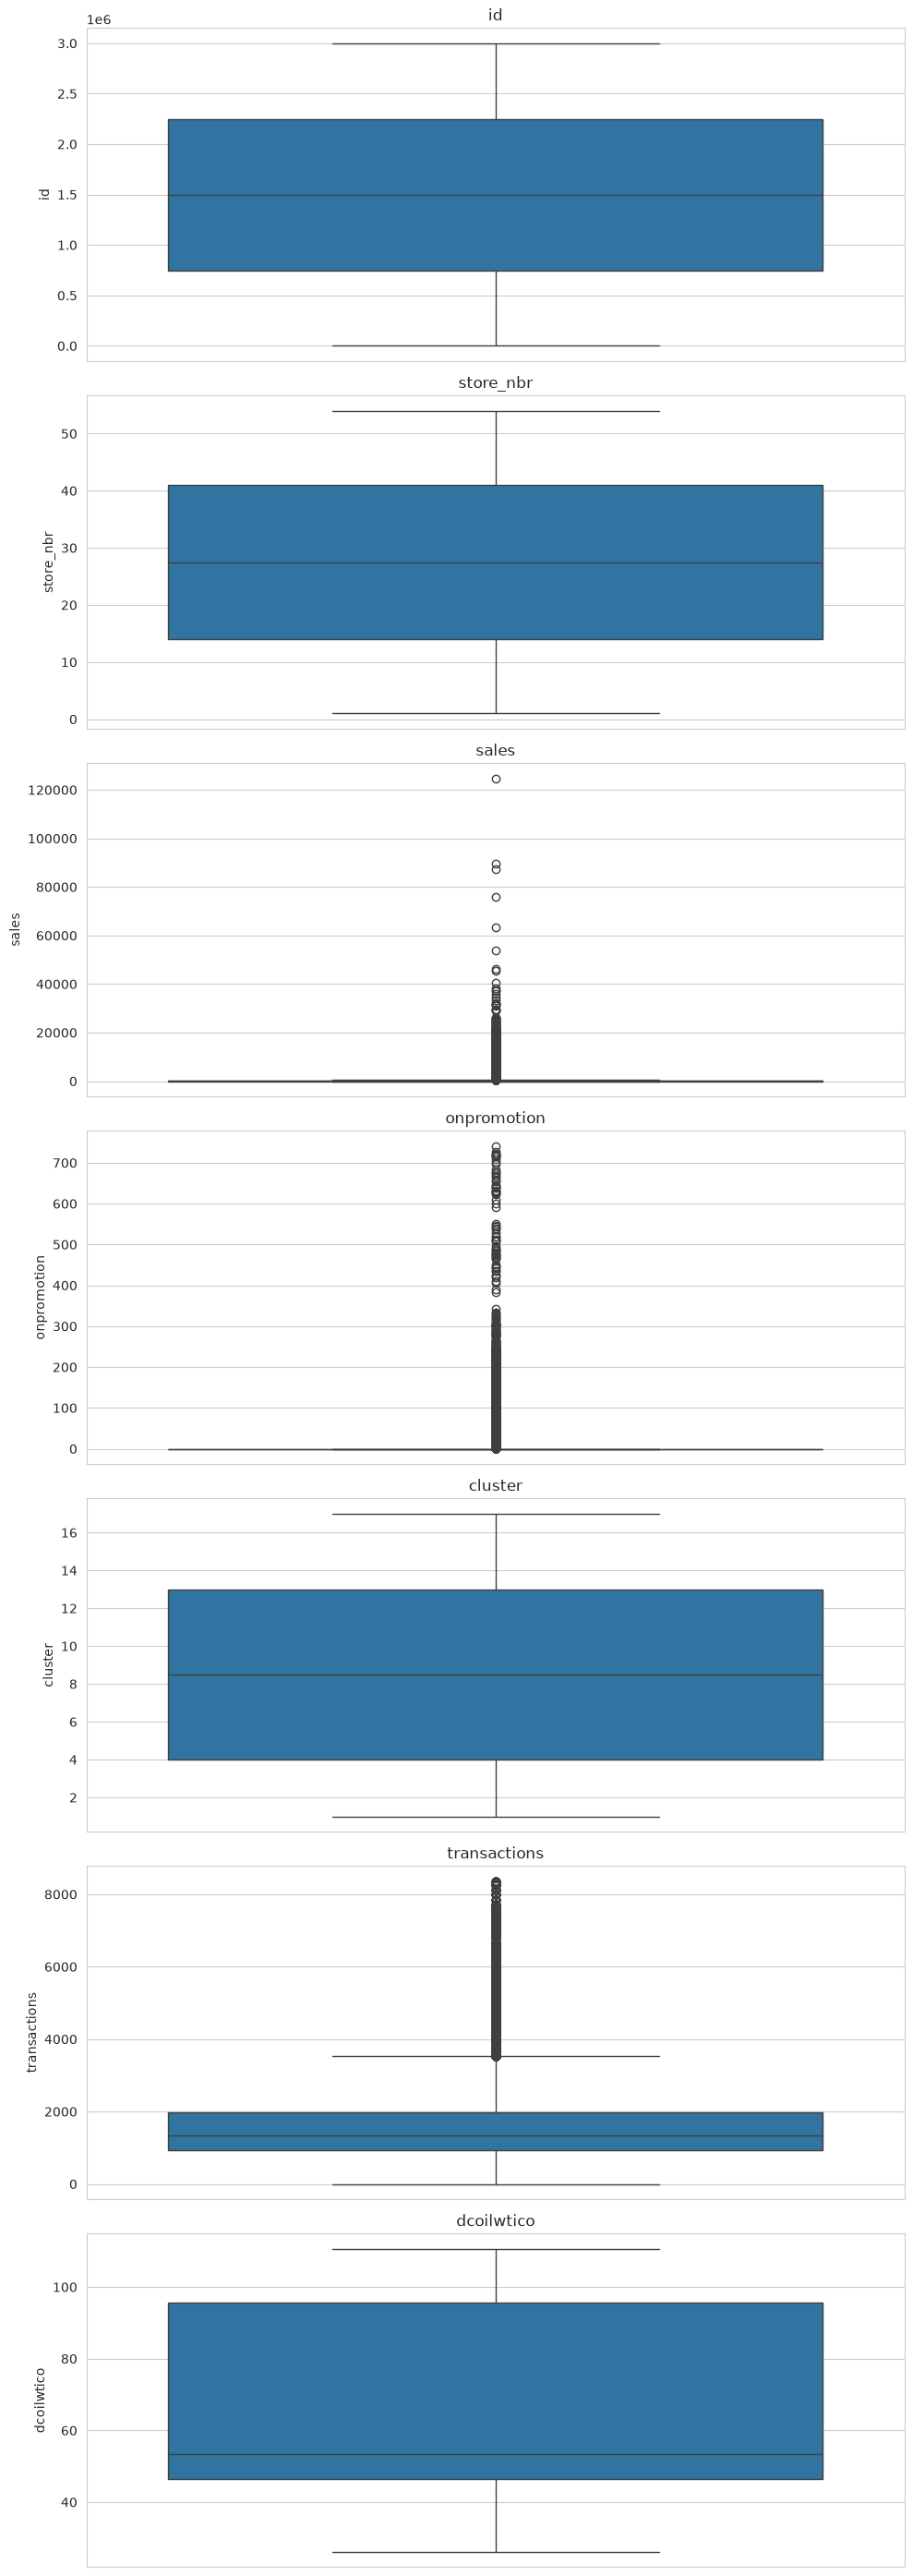

In [321]:
fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(10, 4 * len(numeric_columns)))
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(data=stores_sales, y=column, ax=ax)
    ax.set_title(column)
plt.tight_layout()

## Index and Column Cleanup

Two final preparation steps before moving to EDA:

- **`date` as index**: since this is a time series problem, setting the date as the index enables time-based slicing, resampling, and lag operations natively in pandas.
- **Drop `id`**: the row identifier carries no predictive signal and is removed to keep the feature space clean.

In [322]:
stores_sales.set_index('date', inplace=True)
stores_sales.sort_index(inplace=True)
stores_sales.drop(columns=['id'], inplace=True)
stores_sales.head()

,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,is_national,is_regional,is_local,is_holiday,is_transfer,is_event,is_additional,is_bridge
date,,,,,,,,,,,,,,,,,,
2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,93.14,True,False,False,True,False,False,False,False
2013-01-01,42,CELEBRATION,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,True,False,False,True,False,False,False,False
2013-01-01,42,BREAD/BAKERY,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,True,False,False,True,False,False,False,False
2013-01-01,42,BOOKS,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,True,False,False,True,False,False,False,False
2013-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,True,False,False,True,False,False,False,False


In [323]:
stores_sales.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3000888 entries, 2013-01-01 to 2017-08-15
Data columns (total 18 columns):
 #   Column         Dtype  
---  ------         -----  
 0   store_nbr      int64  
 1   family         str    
 2   sales          float64
 3   onpromotion    int64  
 4   city           str    
 5   state          str    
 6   type           str    
 7   cluster        int64  
 8   transactions   float64
 9   dcoilwtico     float64
 10  is_national    bool   
 11  is_regional    bool   
 12  is_local       bool   
 13  is_holiday     bool   
 14  is_transfer    bool   
 15  is_event       bool   
 16  is_additional  bool   
 17  is_bridge      bool   
dtypes: bool(8), float64(3), int64(3), str(4)
memory usage: 274.7 MB


# Exploratory Data Analysis Questions

1. Which stores concentrate the highest total sales volume, and is there a relationship between store type, geographic cluster, or city and that volume?
2. Are there stores that consistently record days with zero sales? If so, do they follow a pattern (day of the week, time of year) or are they isolated anomalies?
3. Which product families account for the largest share of aggregate sales, and is that concentration consistent across stores or does it vary by location?
4. Does promoting a product have a measurable effect on its sales? Is that effect uniform across product families or do some families respond more than others?
5. Is there a clear seasonal pattern in aggregate sales at the weekly and monthly level? Are there months or days of the week that systematically concentrate more sales?
6. Do sales increase in the second half of the month (days 16–31)? Is this pattern consistent across all stores or does it vary?
7. Does the oil price correlate with aggregate sales over time? When the price falls, do sales rise, fall, or show no apparent relationship?
8. Do holidays generate an increase or decrease in aggregate sales compared to non-holiday days? Is the effect different for national, regional, and local holidays?
9. Did the earthquake of April 16, 2016 affect aggregate sales? Which product families showed the largest change on the earthquake day compared to normal Saturdays, and how quickly did weekly sales recover?

## 1. Which stores concentrate the highest total sales volume, and is there a relationship between store type, geographic cluster, or city and that volume?

In [324]:
sales_per_store=stores_sales.groupby('store_nbr').agg({'sales': 'sum'})
sales_per_store['store_nbr'] = sales_per_store.index

In [325]:
sales_per_store.sort_values(by='sales', ascending=False, inplace=True)
others=sales_per_store.iloc[10:].sum()
sales_per_store = sales_per_store.iloc[:10]
sales_per_store.loc[len(sales_per_store)] = others
sales_per_store

,sales,store_nbr
store_nbr,,
44,6.208755e+07,44.0
45,5.449801e+07,45.0
47,5.094831e+07,47.0
3,5.048191e+07,3.0
49,4.342010e+07,49.0
46,4.189606e+07,46.0
48,3.593313e+07,48.0
51,3.291149e+07,51.0
8,3.049429e+07,8.0


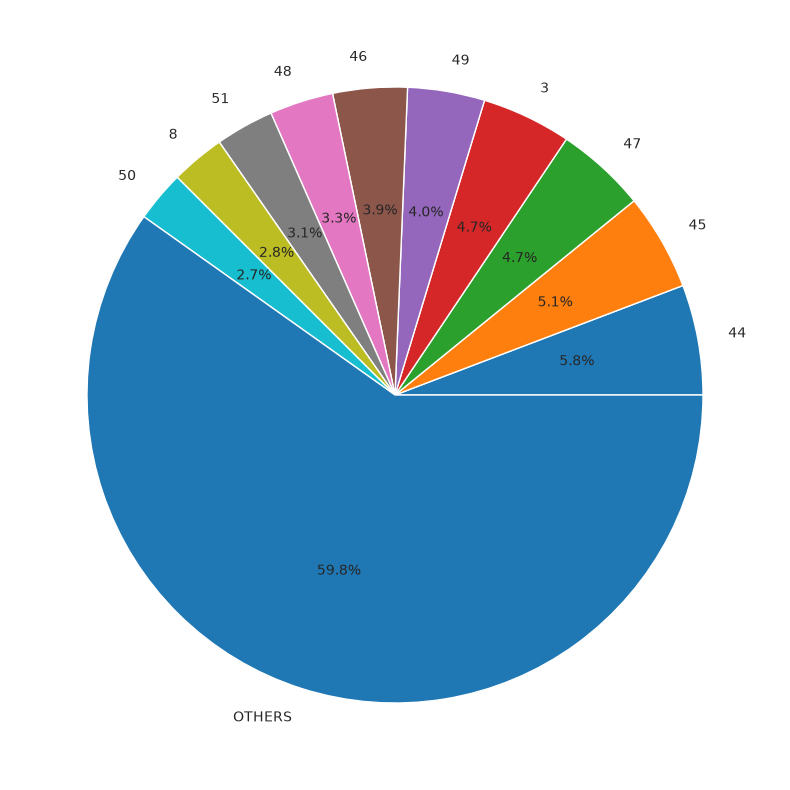

In [326]:
sns.set_style("whitegrid") 
plt.figure(figsize=(10,10)) 
plt.pie(sales_per_store['sales'], labels=['44', '45', '47', '3', '49 ', '46', '48', '51', '8', '50', 'OTHERS'], autopct='%1.1f%%') 
plt.show() 

<Axes: xlabel='sales', ylabel='city'>

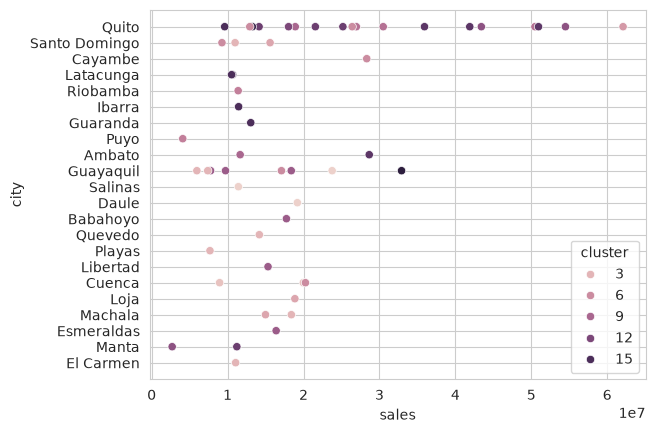

In [330]:
sales_per_store=stores_sales.groupby('store_nbr').agg({'sales': 'sum', 'city': 'first', 'cluster': 'first', 'type': 'first'})
sns.scatterplot(data=sales_per_store, x="sales", y="city", hue='cluster')


<Axes: xlabel='sales', ylabel='city'>

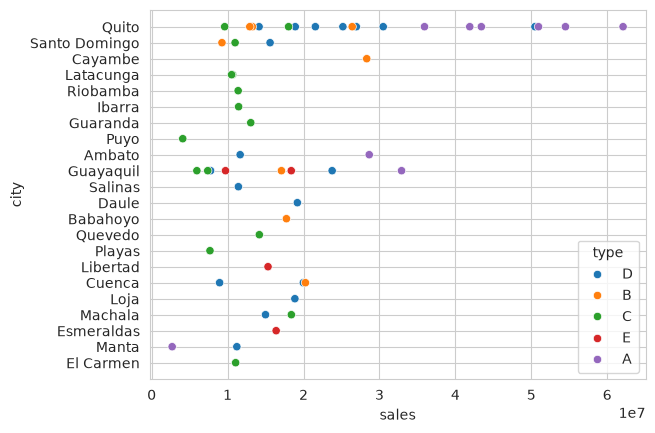

In [331]:
sns.scatterplot(data=sales_per_store, x="sales", y="city", hue='type')

**Conclusions:**

- Stores 44, 45, and 47 lead in total sales volume, each accounting for roughly 3–4% of aggregate revenue. The top 10 stores together represent the minority of stores but a substantial share of total sales.
- **City** is the strongest driver: Quito concentrates the most stores and the highest-selling ones, followed at a distance by Guayaquil and Santo Domingo. Cities with fewer stores (Manta, Guaranda, Puyo) consistently show lower volumes.
- **Store type A** tends to appear at the higher end of the sales distribution, suggesting larger-format stores generate more revenue — but with notable exceptions.
- **Cluster** shows no clear linear relationship with sales. Stores in the same cluster can have very different volumes depending on city and format.
- **Key insight**: neither city, type, nor cluster alone explains sales volume. It is their combination that drives differences — a type A store in Quito vastly outsells a type A store in a smaller city.

## 2. Are there stores that consistently record days with zero sales? If so, do they follow a pattern (day of the week, time of year) or are they isolated anomalies?

In [ ]:
sales_per_store = stores_sales.groupby(['store_nbr', stores_sales.index]).agg({'sales': 'sum'})
sales_zero=sales_per_store[sales_per_store['sales'] == 0]
sales_zero

sales  is_holiday  is_bridge  is_event  is_additional  \
store_nbr date                                                                
1         2013-01-01    0.0        True      False     False          False   
          2014-01-01    0.0        True      False     False          False   
          2015-01-01    0.0        True      False     False          False   
          2015-07-07    0.0       False      False     False          False   
          2016-01-01    0.0        True      False     False          False   
...                     ...         ...        ...       ...            ...   
54        2013-01-01    0.0        True      False     False          False   
          2014-01-01    0.0        True      False     False          False   
          2015-01-01    0.0        True      False     False          False   
          2016-01-01    0.0        True      False     False          False   
          2017-01-01    0.0        True      False     False          False   

                      is_transfer  
store_nbr date                     
1         2013-01-01        False  
          2014-01-01        False  
          2015-01-01        False  
          2015-07-07        False  
          2016-01-01        False  
...                           ...  
54        2013-01-01        False  
          2014-01-01        False  
          2015-01-01        False  
          2016-01-01        False  
          2017-01-01        False  

[7330 rows x 6 columns]

We aggregate total daily sales per store (summing all product families), then isolate store–day combinations where total sales equal zero.

In [ ]:
stores_count_zero_sales=sales_zero.groupby('store_nbr').size()
stores_count_zero_sales.sort_values(ascending=False, inplace=True)


store_nbr
52    1566
22    1011
42     962
21     934
29     808
20     773
53     515
36     131
18     115
24     106
25      66
12      65
14      43
30      28
43       9
17       7
1        6
6        5
2        5
5        5
4        5
3        5
19       5
15       5
16       5
8        5
10       5
9        5
11       5
13       5
7        5
31       5
33       5
32       5
27       5
26       5
28       5
23       5
38       5
37       5
35       5
34       5
41       5
44       5
40       5
39       5
46       5
45       5
47       5
48       5
50       5
49       5
51       5
54       5
dtype: int64

<Axes: xlabel='store_nbr'>

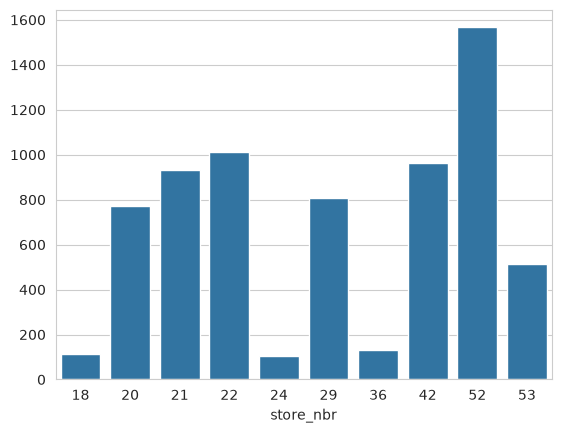

In [350]:
sns.barplot(stores_count_zero_sales.iloc[:10])

Bar chart of the 10 stores with the most zero-sales days. Store 52 stands out with over 1,500 — far above the rest. The dataset covers **1,684 unique dates** in total, so store 52 had zero sales on ~93% of all days.

In [ ]:
stores_sales.index.nunique()

1684

Total number of unique dates in the dataset — used as the denominator to contextualise the zero-sales counts above.

<Axes: xlabel='date', ylabel='sales'>

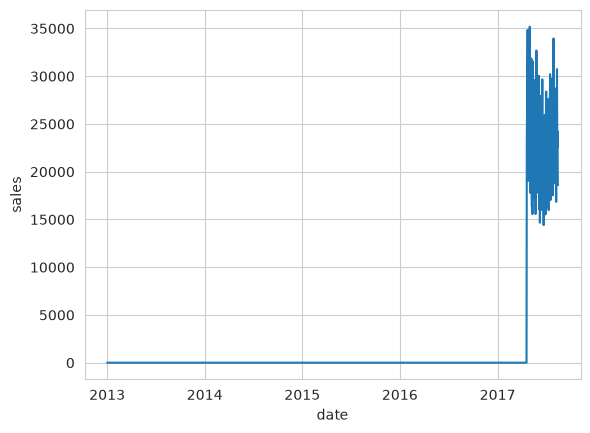

In [356]:
store_sales = stores_sales[stores_sales['store_nbr'] == 52]
total_sales_store = store_sales.groupby([store_sales.index]).agg({'sales': 'sum'})
sns.lineplot(data=total_sales_store, x=total_sales_store.index, y='sales')

To determine whether the zeros are random or structural, we plot daily sales over time for store 52 — the most affected store.

**Conclusions:**

- A small group of stores records a disproportionately high number of zero-sales days. Store 52 is the extreme case, with zero sales on ~93% of all dates in the dataset.
- The line plot reveals that the zeros are **not random**: store 52 had virtually no sales from 2013 through mid-2016, then began operating normally from 2017 onward. This is consistent with a store that opened late in the data period, not one that was open but underperforming.
- For the remaining stores with occasional zeros (5–100 days), these likely correspond to national holidays when all stores are closed — a systematic pattern rather than isolated anomalies.
- **Implication for modelling**: store 52 should be treated carefully in training. Its sales history is too short relative to other stores, and lags or rolling averages computed over the full period would be dominated by zeros.

## 3. Which product families account for the largest share of aggregate sales, and is that concentration consistent across stores or does it vary by location?

Total sales per product family, aggregated across all stores and dates. The top 10 families are shown to focus on the most relevant categories.

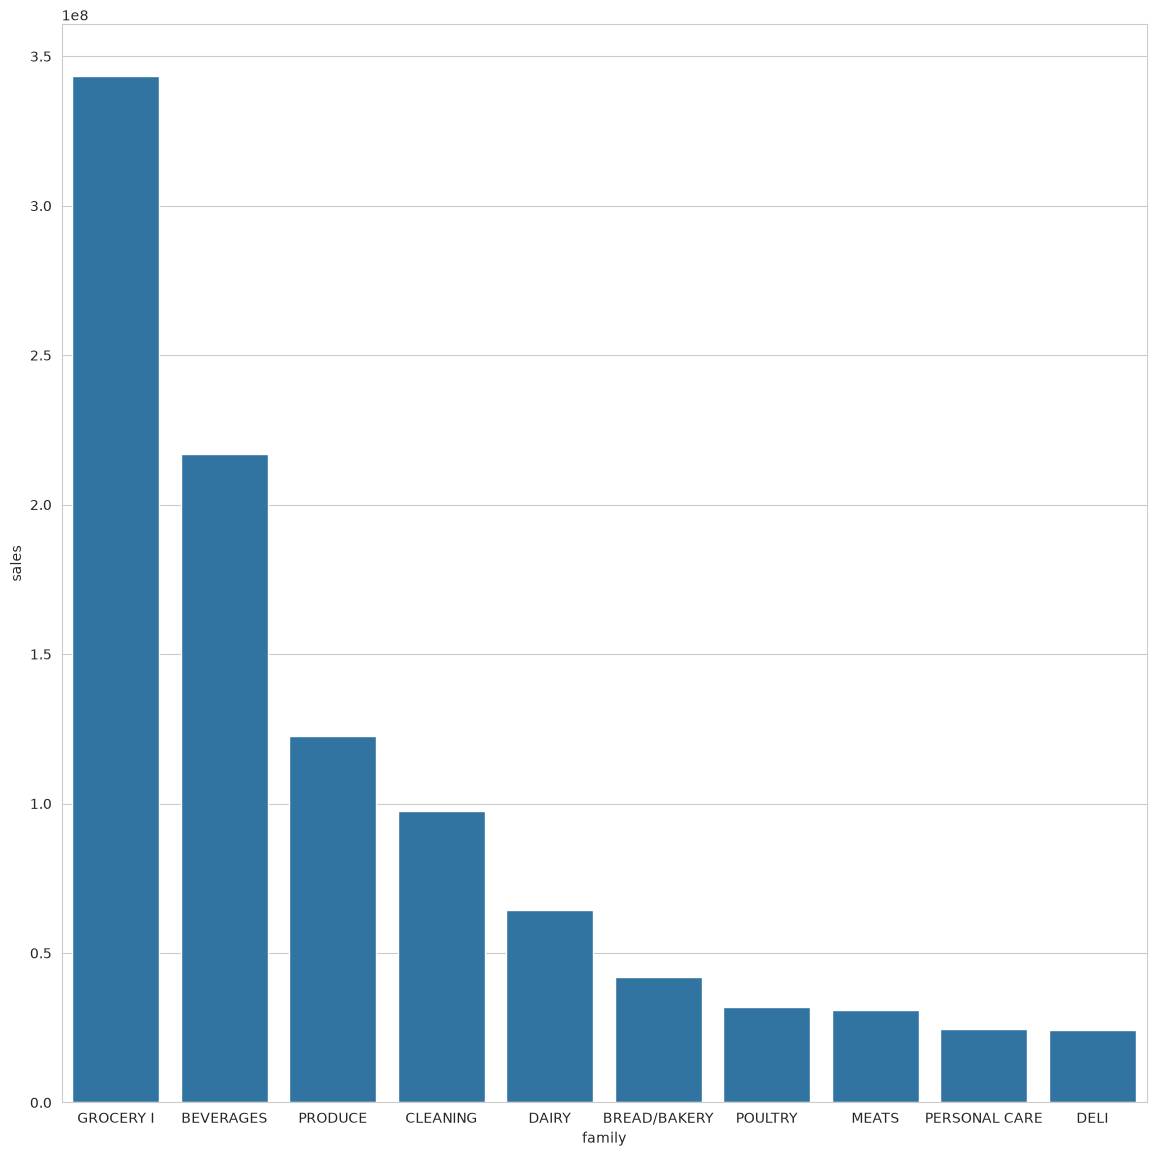

In [491]:
family_sales = stores_sales.groupby('family').agg({'sales': 'sum'})
family_sales.sort_values(by='sales', ascending=False, inplace=True)
family_sales = family_sales.iloc[:10]
plt.figure(figsize=(14,14)) 
sns.barplot(family_sales, x=family_sales.index, y='sales')
plt.show()

To check whether this ranking is consistent across stores, we compute total sales per family per store, then extract the top-selling family for each store.

In [389]:
family_sales = stores_sales.groupby(['family', 'store_nbr']).agg({'sales': 'sum'})
family_sales.sort_values(by='sales', ascending=False, inplace=True)
family_sales.reset_index(inplace=True)
family_sales=family_sales.groupby('store_nbr').agg({'sales': 'first', 'family': 'first'})
family_sales

,sales,family
store_nbr,,
1,3.743823e+06,GROCERY I
2,6.591704e+06,GROCERY I
3,1.297047e+07,GROCERY I
4,5.636344e+06,GROCERY I
5,5.262682e+06,GROCERY I
6,7.806646e+06,GROCERY I
7,6.247974e+06,GROCERY I
8,7.909966e+06,GROCERY I
9,1.035310e+07,GROCERY I


In [ ]:
family_sales[family_sales['family'] != 'GROCERY I']

**Conclusions:**

- **GROCERY I** is the top-selling product family by a wide margin, generating nearly 60% more revenue than the second family (BEVERAGES). The concentration is driven by everyday staple goods.
- The ranking is **almost universal**: GROCERY I leads in 53 out of 54 stores. Store 25 is the only exception, where BEVERAGES ranks first — likely reflecting a specific store format or local customer preference.
- **Implication for modelling**: GROCERY I will have a disproportionate influence on aggregate sales metrics. Model performance should be evaluated per family to avoid the dominant families masking poor predictions in smaller ones.

## 4. Does promoting a product have a measurable effect on its sales? Is that effect uniform across product families or do some families respond more than others?

We split the dataset into days with and without promotion (`onpromotion > 0` vs `== 0`) and compare mean daily sales per family. Using the mean rather than the sum avoids bias from the unequal number of promoted vs non-promoted days.

<Axes: ylabel='family'>

<Figure size 700x700 with 0 Axes>

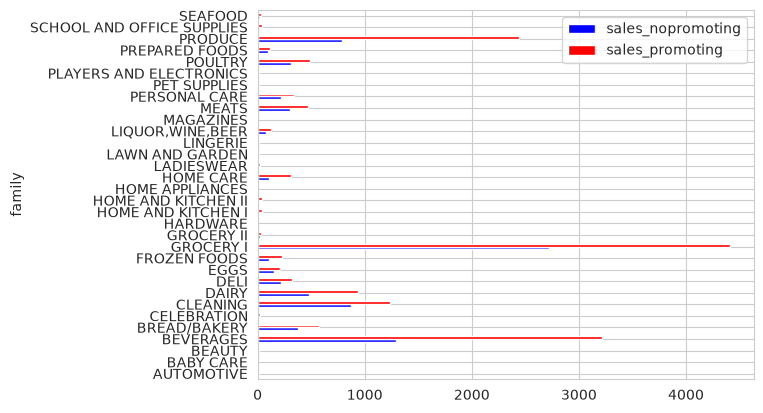

In [502]:
stores_sales_promoting = stores_sales[stores_sales['onpromotion'] > 0]
stores_sales_nopromoting = stores_sales[stores_sales['onpromotion'] == 0]

family_sales_promoting = stores_sales_promoting.groupby('family').agg({'sales': 'mean'})
family_sales_nopromoting = stores_sales_nopromoting.groupby('family').agg({'sales': 'mean'})

family_sales_nopromoting.reset_index(inplace=True)
family_sales_promoting.reset_index(inplace=True)

family_sales_nopromoting.rename(columns={'sales': 'sales_nopromoting'}, inplace=True)
family_sales_promoting.rename(columns={'sales': 'sales_promoting'}, inplace=True)
sales_promo_nopromo = pd.DataFrame(data=family_sales_nopromoting, columns=family_sales_nopromoting.columns.to_list())
sales_promo_nopromo=sales_promo_nopromo.merge(family_sales_promoting, left_on="family", right_on="family")


plt.figure(figsize=(7,7)) 
sales_promo_nopromo.plot(x="family", y=["sales_nopromoting", "sales_promoting"], kind="barh", rot=0, color=['blue', 'red'])

Promotional lift per family: `(sales_promo - sales_nopromo) / (sales_promo + sales_nopromo) * 100`. Positive values mean promotion increases average daily sales.

In [410]:
sales_promo_nopromo['diff']=(sales_promo_nopromo['sales_promoting']- sales_promo_nopromo['sales_nopromoting']) *100/ (sales_promo_nopromo['sales_promoting']+ sales_promo_nopromo['sales_nopromoting'])
sales_promo_nopromo

,family,sales_nopromoting,sales_promoting,diff
0,AUTOMOTIVE,5.853087,13.241978,38.695290
1,BABY CARE,0.109624,1.660377,87.613068
2,BEAUTY,3.078452,8.291266,45.848218
3,BEVERAGES,1292.272591,3215.498308,42.664673
4,BREAD/BAKERY,379.513249,575.485296,20.520664
5,CELEBRATION,7.945922,19.969168,43.070778
6,CLEANING,868.378326,1240.210741,17.634181
7,DAIRY,479.811128,933.341720,32.093527
8,DELI,221.763382,321.665801,18.383705
9,EGGS,154.703932,210.019941,15.166545


<Axes: xlabel='diff', ylabel='family'>

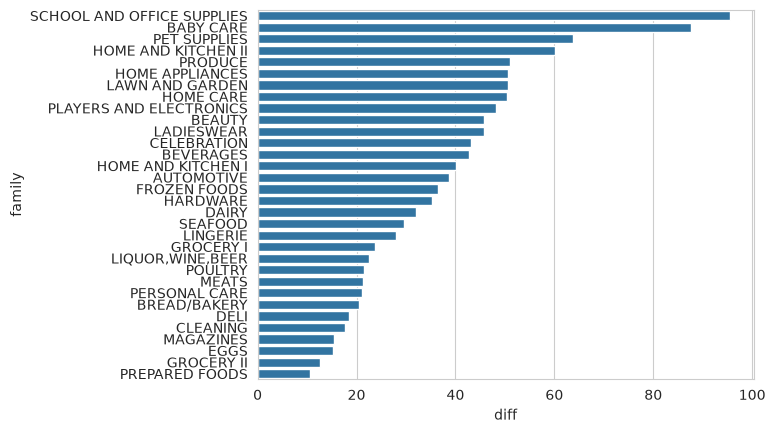

In [489]:
sales_promo_nopromo.sort_values(by='diff', ascending=False, inplace=True)
sns.barplot(sales_promo_nopromo, x="diff", y="family")

**Conclusions:**

- Promotions have a **measurable positive effect** across all 33 families — average daily sales are higher on promoted days in every case.
- The effect is **highly heterogeneous**. SCHOOL AND OFFICE SUPPLIES (96%) and BABY CARE (88%) show the strongest lift — near-doubling sales on promoted days. PET SUPPLIES (64%) and HOME AND KITCHEN II (60%) also respond strongly.
- Staple categories respond much less: PREPARED FOODS (11%), GROCERY II (13%), and EGGS (15%) show the weakest lift — these are habitual purchases that customers make regardless of promotions.
- **Implication for modelling**: `onpromotion` is a strong feature, but its predictive power varies widely by family. A model that captures the interaction between `onpromotion` and `family` will outperform one that treats the promotion effect as uniform.

## 5. Is there a clear seasonal pattern in aggregate sales at the weekly and monthly level? Are there months or days of the week that systematically concentrate more sales?

In [470]:
stores_sales_seasonal_pattern = stores_sales.copy()
stores_sales_seasonal_pattern['day'] = stores_sales_seasonal_pattern.index.dayofweek
stores_sales_seasonal_pattern['month'] = stores_sales_seasonal_pattern.index.month
stores_sales_seasonal_pattern['week'] = stores_sales_seasonal_pattern.index.isocalendar().week.values

In [471]:
stores_sales_seasonal_pattern['day']=stores_sales_seasonal_pattern['day'].map({0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"})
stores_sales_seasonal_pattern['month']=stores_sales_seasonal_pattern['month'].map({1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8:"August", 9: "September", 10:"October", 11:"November", 12:"December"})
stores_sales_seasonal_pattern.head()

,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,...,is_regional,is_local,is_holiday,is_transfer,is_event,is_additional,is_bridge,day,month,week
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,93.14,...,False,False,True,False,False,False,False,Tuesday,January,1
2013-01-01,42,CELEBRATION,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,...,False,False,True,False,False,False,False,Tuesday,January,1
2013-01-01,42,BREAD/BAKERY,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,...,False,False,True,False,False,False,False,Tuesday,January,1
2013-01-01,42,BOOKS,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,...,False,False,True,False,False,False,False,Tuesday,January,1
2013-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,...,False,False,True,False,False,False,False,Tuesday,January,1


In [472]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
stores_sales_seasonal_pattern['month'] = pd.Categorical(stores_sales_seasonal_pattern['month'], categories=month_order, ordered=True)
stores_sales_seasonal_pattern.sort_values('month', inplace=True)


In [473]:
sales_per_day = stores_sales_seasonal_pattern.groupby('day').agg({'sales': 'mean'})
sales_per_week = stores_sales_seasonal_pattern.groupby('week').agg({'sales': 'mean'})
sales_per_month = stores_sales_seasonal_pattern.groupby('month').agg({'sales': 'mean'})

<Axes: xlabel='sales', ylabel='day'>

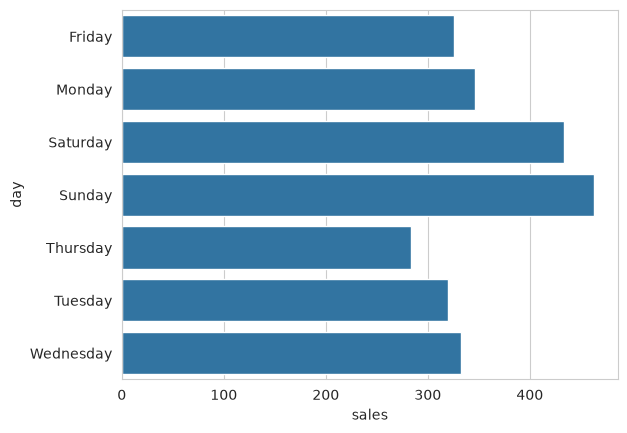

In [474]:
sns.barplot(sales_per_day, x="sales", y=sales_per_day.index)

<Axes: xlabel='week', ylabel='sales'>

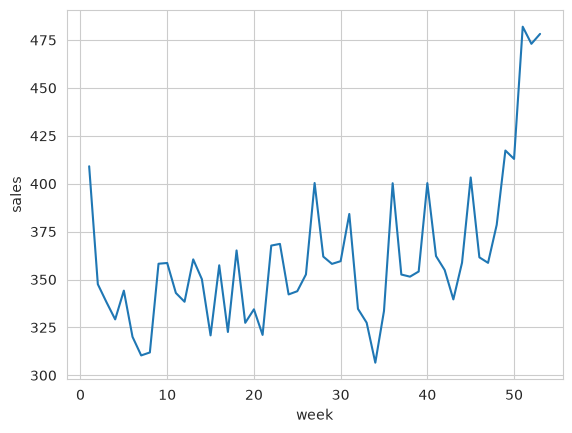

In [475]:
sns.lineplot(sales_per_week, x=sales_per_week.index, y="sales")

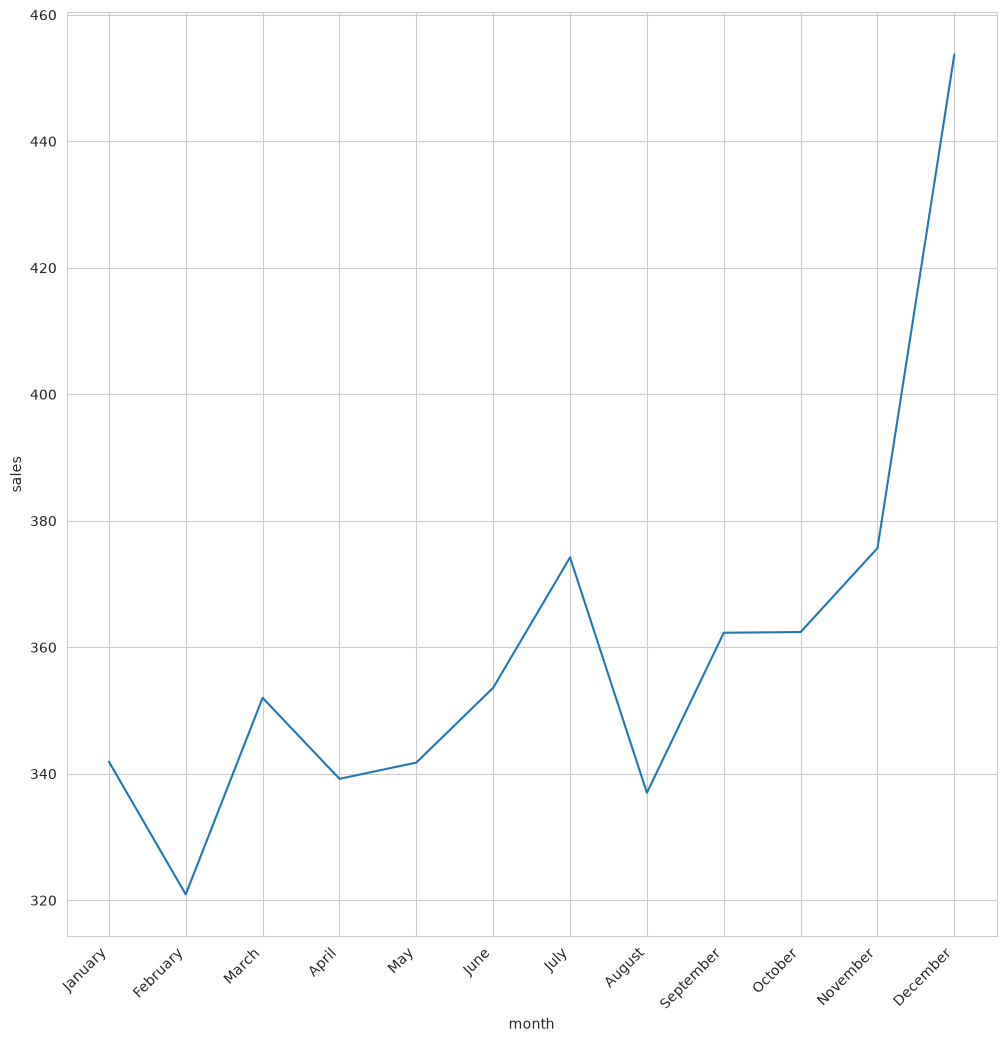

In [476]:
plt.figure(figsize=(12,12))
sns.lineplot(sales_per_month, x=sales_per_month.index, y="sales")
plt.xticks(rotation=45, ha='right')
plt.show()

**Conclusions:**

- **By day of the week**: Sunday and Saturday concentrate the highest average daily sales — the weekend effect is clear and consistent. Thursday is the weakest day, followed closely by Tuesday and Friday. Customers concentrate their shopping at the end of the week.
- **By week of the year**: sales are relatively stable between weeks 1–45, with week 52 standing out as the highest point. This reflects the Christmas and New Year period, where average daily sales peak. The previous reading of week 52 as an artifact was based on `sum` — switching to `mean` corrects that distortion and reveals the true pattern.
- **By month**: two clear minimums — February (~321) is the lowest month, and August (~337) is a secondary dip, likely driven by post–back-to-school spending fatigue after the July peak. July shows a mid-year surge consistent with school supply purchases. The trend then climbs steadily from September through December, which is the peak month (~453), driven by year-end consumption and holidays.
- **Implication for modelling**: day of the week, week number, and month are strong temporal features. The weekend effect and the December peak are the most reliable signals in the dataset and should be included as explicit features in the model.

## 6. Do sales increase in the second half of the month (days 16–31)? Is this pattern consistent across all stores or does it vary?

In [481]:
stores_sales_15th = stores_sales.copy()
stores_sales_15th['is_second_half'] = stores_sales_15th.index.day > 15 
stores_sales_15th = stores_sales_15th.groupby('is_second_half').agg({'sales': 'mean'})

<Axes: xlabel='is_second_half', ylabel='sales'>

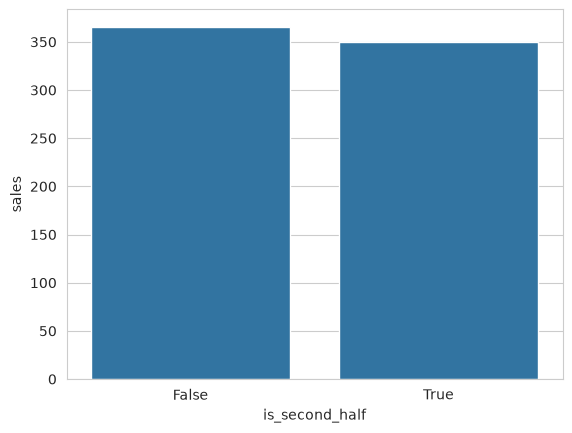

In [482]:
sns.barplot(stores_sales_15th, x=stores_sales_15th.index, y="sales")

In [485]:
stores_sales_15th = stores_sales.copy()
stores_sales_15th['is_second_half'] = stores_sales_15th.index.day > 15 
stores_sales_15th = stores_sales_15th.groupby(['is_second_half', 'store_nbr']).agg({'sales': 'mean'})
stores_sales_15th.reset_index(inplace=True)


([], [])

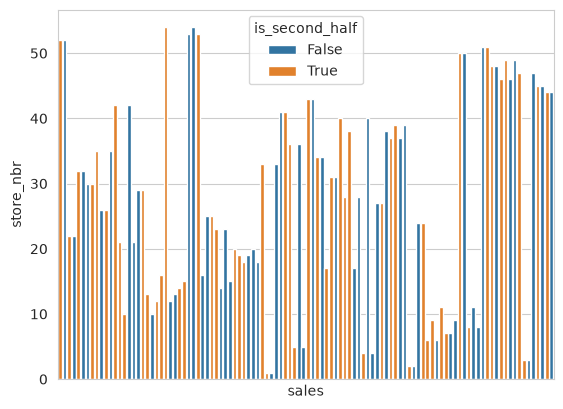

In [486]:
sns.barplot(stores_sales_15th, x="sales", y="store_nbr", hue="is_second_half")
plt.xticks([])

**Conclusions:**

- At the aggregate level, the difference between the first and second half of the month is minimal (~4%) and slightly favours the first half — the opposite of what a payday effect would predict.
- The store-by-store breakdown confirms this: across virtually all 54 stores, the orange (second half) and blue (first half) bars are near-identical. There is no store where the second half consistently and clearly outperforms the first.
- **Implication for modelling**: `is_second_half` does not appear to be a useful feature. The absence of a payday effect suggests that purchasing behaviour in this dataset is driven more by day-of-week and seasonal patterns than by within-month pay cycles.

## 7. Does the oil price correlate with aggregate sales over time? When the price falls, do sales rise, fall, or show no apparent relationship?

In [700]:
oil_sales = stores_sales.copy()
oil_sales = oil_sales.groupby(oil_sales.index.to_period('M')).agg({'sales': 'mean', 'dcoilwtico': 'mean'})

In [701]:
oil_sales

,sales,dcoilwtico
date,,
2013-01,186.952405,94.632258
2013-02,193.581846,95.403571
2013-03,206.880581,93.217097
2013-04,205.639071,91.793000
2013-05,209.943594,94.654516
2013-06,218.655893,95.584333
2013-07,203.783364,104.776774
2013-08,212.479434,106.666452
2013-09,220.593588,106.491000


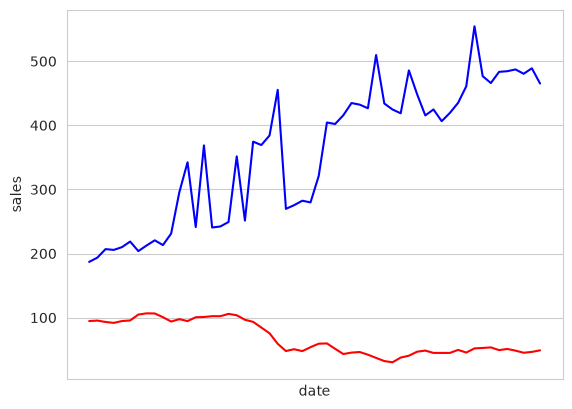

In [702]:
oil_sales.index = oil_sales.index.astype('str')
sns.lineplot(data=oil_sales, y="sales", x=oil_sales.index, color='blue')
sns.lineplot(data=oil_sales, y="dcoilwtico", x=oil_sales.index, color='red')
plt.xticks([])
plt.show()

In [703]:
oil_sales.corr()

,sales,dcoilwtico
sales,1.000000,-0.787837
dcoilwtico,-0.787837,1.000000


In [704]:
oil_sales_diff = oil_sales.diff().dropna()
oil_sales_diff.corr()


,sales,dcoilwtico
sales,1.000000,0.049412
dcoilwtico,0.049412,1.000000


**Conclusions:**

- The Pearson correlation between monthly mean sales and oil price is **-0.79** — a strong negative value. As oil prices fell from ~$95 (2013) to ~$30 (early 2016), aggregate sales rose steadily.
- However, this correlation is **spurious**. Ecuador is an oil-exporting country: falling oil prices reduce government revenue and should theoretically hurt consumer spending — the opposite of what the raw correlation suggests.
- The more plausible explanation is that both series follow independent time trends over 2013–2017: sales grow due to Favorita's organic expansion (more stores, more customers), while oil falls due to global market forces. Two simultaneous trends in opposite directions produce high correlation without any causal link.
- This is confirmed by **differencing**: after removing the time trend (`oil_sales.diff()`), the correlation between month-over-month changes in sales and oil price drops to **0.05** — essentially zero. There is no real relationship between the two variables once the common trend is eliminated.
- **Implication for modelling**: `dcoilwtico` can still be included as a feature — it may capture some macroeconomic signal — but it should not be interpreted as a causal driver of sales. Using it in differenced form or alongside explicit time features is advisable to avoid introducing spurious signal.

## 8. Do holidays generate an increase or decrease in aggregate sales compared to non-holiday days? Is the effect different for national, regional, and local holidays?

<Axes: xlabel='is_holiday', ylabel='sales'>

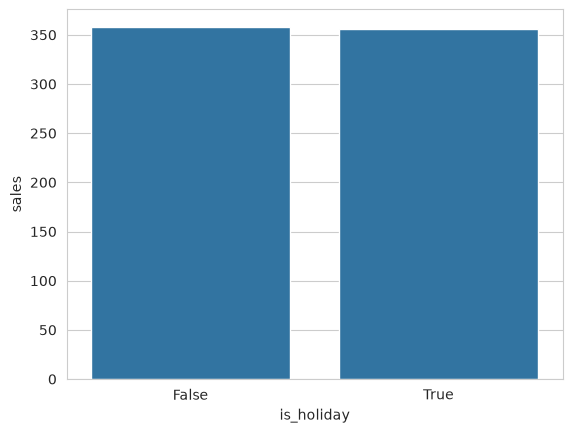

In [695]:
holidays_sales = stores_sales.groupby('is_holiday').agg({'sales': 'mean'})
sns.barplot(data=holidays_sales, x=holidays_sales.index, y="sales")

In [696]:
national_holiday_sales = stores_sales.groupby('is_national').agg({'sales': 'mean'})
regional_holiday_sales = stores_sales.groupby('is_regional').agg({'sales': 'mean'})
local_holiday_sales = stores_sales.groupby('is_local').agg({'sales': 'mean'})
holiday_sales = stores_sales.groupby('is_holiday').agg({'sales': 'mean'})


In [697]:
holidays_comparison = pd.DataFrame(columns=['holiday_type', 'mean_sales'])
holidays_comparison.loc[len(holidays_comparison)] = ['No Holidays', holiday_sales.loc[False, 'sales']]
holidays_comparison.loc[len(holidays_comparison)] = ['National', national_holiday_sales.loc[True, 'sales']]
holidays_comparison.loc[len(holidays_comparison)] = ['Regional', regional_holiday_sales.loc[True, 'sales']]
holidays_comparison.loc[len(holidays_comparison)] = ['Local', local_holiday_sales.loc[True, 'sales']]


In [698]:
holidays_comparison

,holiday_type,mean_sales
0,No Holidays,357.917648
1,National,412.577102
2,Regional,387.005786
3,Local,363.066318


<Axes: ylabel='holiday_type'>

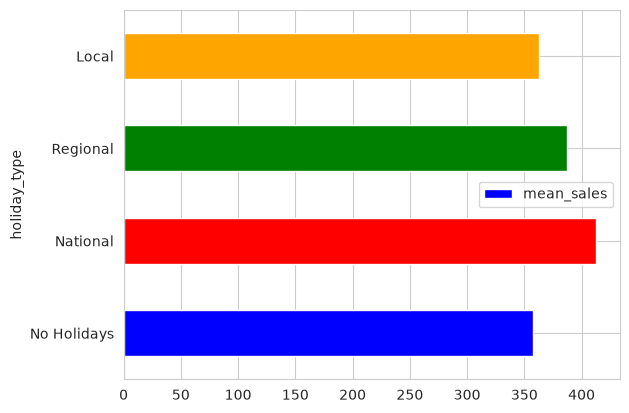

In [699]:
holidays_comparison.plot(x='holiday_type', y='mean_sales', kind="barh", rot=0, color=['blue', 'red', 'green', 'orange'])

**Conclusions:**

- At the aggregate level (`is_holiday` flag), holiday and non-holiday days show nearly identical mean sales (~356 vs ~358). The aggregate flag masks very different effects depending on the locale of the holiday.
- **National holidays** (~413) show the highest mean sales — well above the non-holiday baseline of ~358 (+15%). This is counterintuitive given that some stores close on national holidays. The likely explanation is that the national holiday dates in this dataset include major high-consumption periods (Christmas, Carnival, Easter preparations) where stores that remain open sell significantly more than on a typical day.
- **Regional holidays** (~387) also show higher mean sales (+8% vs baseline). Similar reasoning applies — regional celebrations tend to drive local consumption.
- **Local holidays** (~363) show the smallest boost above baseline (+1%), barely distinguishable from normal days.
- The direction reverses compared to what a simple closure model would predict: holidays do not depress aggregate sales because the high-volume holiday periods dominate the average over low-volume closure days.
- **Implication for modelling**: the raw `is_holiday` flag provides little signal (+0.5% vs baseline). The locale-level flags (`is_national`, `is_regional`) carry more information, but their effect is positive — not negative as one might initially assume. Interaction terms with the month or specific holiday names would be needed to separate closing days from peak shopping days.

## 9. Did the earthquake of April 16, 2016 affect aggregate sales? Which product families showed the largest change on the earthquake day compared to normal Saturdays, and how quickly did weekly sales recover?

In [705]:
earthquake_sales = stores_sales
earthquake_sales=earthquake_sales[earthquake_sales.index.year == 2016]
earthquake_sales = earthquake_sales[((earthquake_sales.index.month > 1) & (earthquake_sales.index.month <= 4)) | ((earthquake_sales.index.month <= 7) & (earthquake_sales.index.month >= 4))]

In [706]:
earthquake_sales_days = earthquake_sales.groupby(earthquake_sales.index).agg({"sales": "mean"})
earthquake_sales_weeks = earthquake_sales.groupby(earthquake_sales.index.to_period('W')).agg({"sales": "mean"})

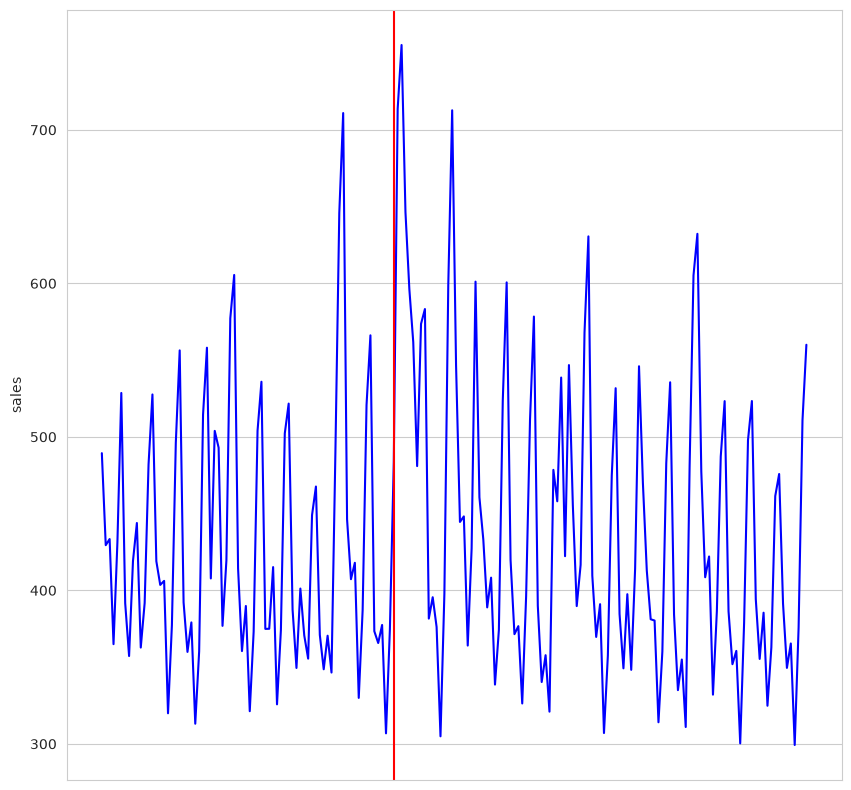

In [707]:
earthquake_sales_days.index = earthquake_sales_days.index.astype('str')
plt.figure(figsize=(10,10))
plt.xticks([])
sns.lineplot(data=earthquake_sales_days, y="sales", x=earthquake_sales_days.index, color='blue')
plt.axvline(x='2016-04-16', color='red')
plt.show()

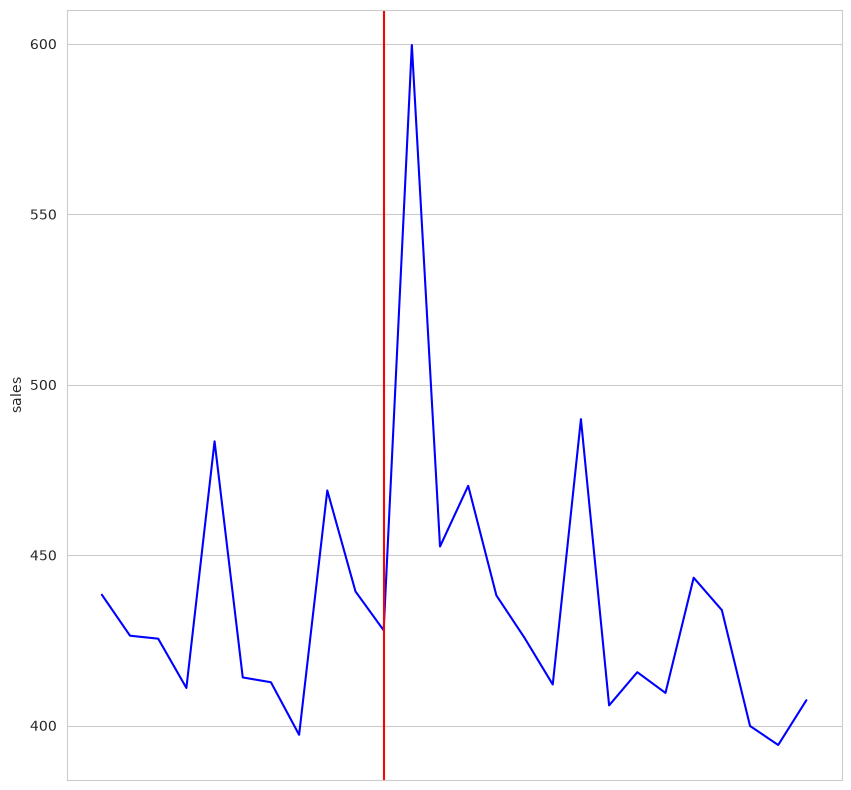

In [708]:
earthquake_sales_weeks.index = earthquake_sales_weeks.index.astype('str')
plt.figure(figsize=(10,10))
plt.xticks([])
sns.lineplot(data=earthquake_sales_weeks, y="sales", x=earthquake_sales_weeks.index, color='blue')
plt.axvline(x='2016-04-11/2016-04-17', color='red')
plt.show()


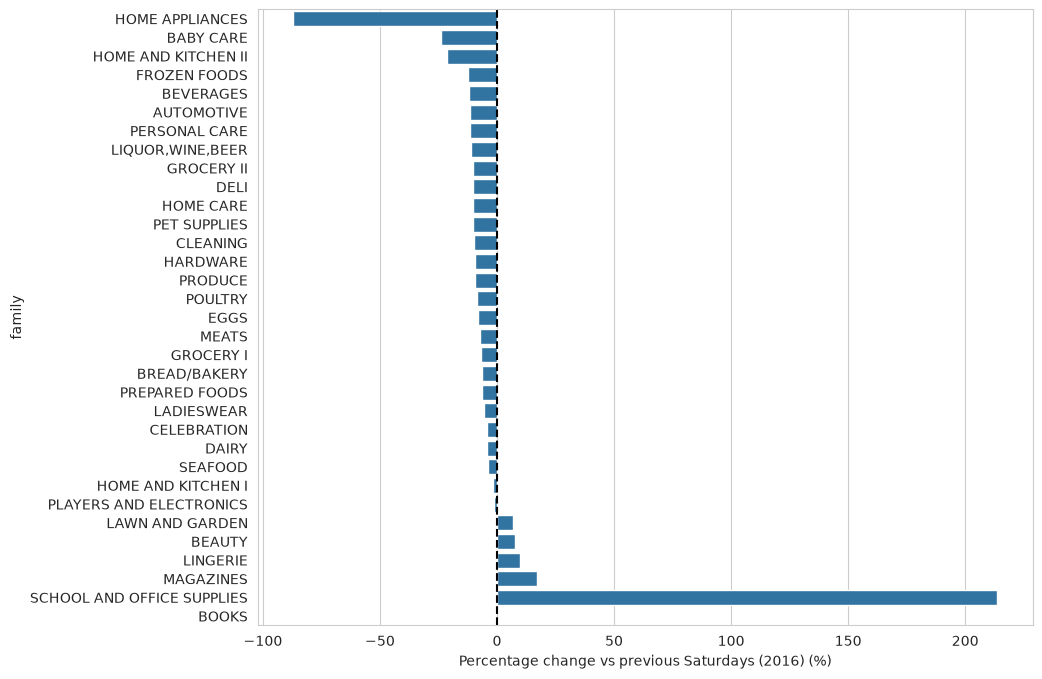

In [709]:

saturdays = stores_sales[stores_sales.index.year == 2016]
saturdays = saturdays[saturdays.index.dayofweek == 5]


eq_saturday = saturdays[saturdays.index == '2016-04-16']
prev_saturdays = saturdays[saturdays.index < '2016-04-16']

eq_sat_family = eq_saturday.groupby('family').agg({'sales': 'mean'})
prev_sat_family = prev_saturdays.groupby('family').agg({'sales': 'mean'})


diff_sat = pd.DataFrame()
diff_sat['mean_prev'] = prev_sat_family['sales']
diff_sat['mean_eq'] = eq_sat_family['sales']
diff_sat['diff'] = (diff_sat['mean_eq'] - diff_sat['mean_prev']) / diff_sat['mean_prev'] * 100
diff_sat = diff_sat.reset_index()
diff_sat = diff_sat.sort_values('diff')

plt.figure(figsize=(10, 8))
sns.barplot(data=diff_sat, x='diff', y='family')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Percentage change vs previous Saturdays (2016) (%)')
plt.show()


Percentage change in mean sales per family on April 16, 2016 vs the average of previous Saturdays in 2016. Comparing the same day of the week controls for the natural Saturday sales premium.

**Conclusions:**

- At the weekly level, aggregate sales show a visible spike in the earthquake week followed by a rapid return to the pre-earthquake oscillation range within 1–2 weeks. There is no evidence of a permanent structural break in total sales.
- On the earthquake day itself (April 16), most product families recorded slight declines relative to normal Saturdays, suggesting that some stores closed or reduced activity on that day.
- **HOME APPLIANCES** shows the largest relative drop (~90%) — expected, as big-ticket non-essential purchases are the first to be deferred in a crisis context.
- **GROCERY I and BEVERAGES** show near-zero change on the day. The panic-buying response likely occurred in the days following the earthquake, not on the day itself.
- Recovery was **rapid**: the weekly series returns to normal within two weeks, suggesting no lasting demand destruction for Favorita's stores at the aggregate level.
- **Implication for modelling**: a binary `is_earthquake_week` flag covering the two weeks around April 16, 2016 would capture this transient disruption without overfitting to a single day.

# EDA Summary

| # | Question | Answer |
|---|----------|--------|
| 1 | Which stores concentrate the highest volume? | Stores 44, 45, 47 lead. City (Quito) is the strongest driver; type A tends higher, but neither city nor type alone explains volume. |
| 2 | Are there stores with systematic zero-sales days? | Store 52 had zeros on 93% of days — it opened late (~2017). Other zeros cluster on national holidays. |
| 3 | Which product families dominate? | GROCERY I leads in 53/54 stores by a wide margin. Store 25 is the only exception (BEVERAGES first). |
| 4 | Does promotion drive sales? | Yes, across all families. SCHOOL AND OFFICE SUPPLIES (+96%) and BABY CARE (+88%) respond most; PREPARED FOODS (+11%) the least. |
| 5 | Is there a seasonal pattern? | Weekends peak (Saturday/Sunday). December is the highest month, February the lowest. Week 52 (Christmas) is the annual maximum. |
| 6 | Do sales increase in the second half of the month? | No. First and second half are virtually identical across all 54 stores — no payday effect. |
| 7 | Does oil price correlate with sales? | Raw correlation is -0.79 but spurious (opposite time trends). After differencing it drops to 0.05 — no real relationship. |
| 8 | Do holidays affect sales? | All holiday types show higher mean sales than non-holiday days. National holidays are highest (+15% vs baseline, ~413 vs ~358), likely driven by major shopping periods (Christmas, Carnival). The aggregate `is_holiday` flag shows near-zero effect. |
| 9 | Did the earthquake disrupt sales? | Slight decline on the earthquake day across most families; HOME APPLIANCES dropped most. No permanent structural break — recovery within 1–2 weeks. |

# Trend, Residuals and Stationality

In [710]:
agg_serie = stores_sales.groupby(stores_sales.index).agg({'sales': 'mean'})


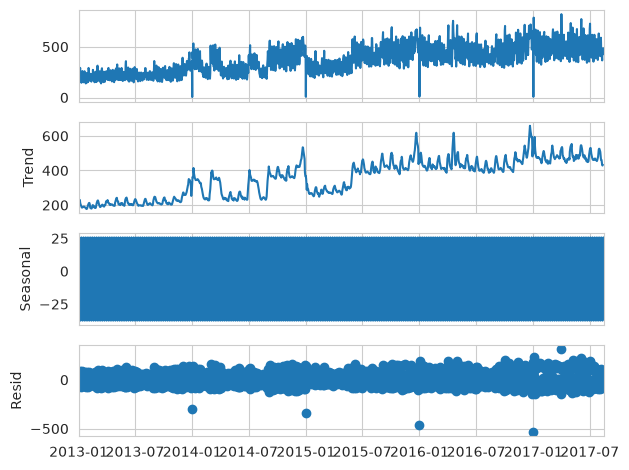

In [711]:
result=seasonal_decompose(x=agg_serie, model='additive', period=7)
result.plot();

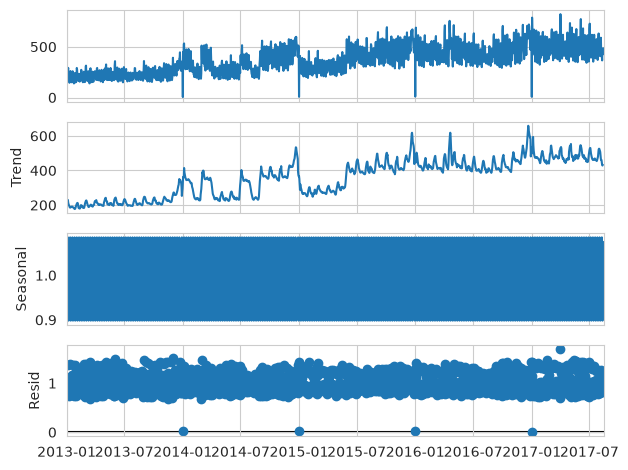

In [712]:
result=seasonal_decompose(x=agg_serie, model='multiplicative', period=7)
result.plot();

**Conclusions:**

- The **additive model** is the correct choice for this dataset. The 31% structural zeros (store closures on holidays) cause the multiplicative model to produce near-zero residuals on those days — division by zero-inflated values distorts the residual component entirely. In the additive model, the same days appear as large negative spikes in the residuals, which is the correct representation of an anomalous event.
- The **trend** shows a clear upward trajectory from ~200 (2013) to ~500 (2017) — approximately 2.5× growth over five years. This reflects a combination of organic sales growth and the progressive opening of new stores (notably store 52, which only began operating in 2017).
- The trend is **not smooth**: it shows regular bumps that repeat approximately every 12 months. These are the annual seasonal patterns (December peak, February trough, July surge) bleeding into the trend component because `period=7` only extracts the weekly cycle. Capturing both weekly and annual seasonality simultaneously would require `STL` with multiple seasonal periods.
- The **seasonal component** shows a stable, fixed-amplitude weekly pattern across the entire series. This supports the additive choice: the seasonal swings do not grow proportionally with the trend level.
- The **residuals** are centred near zero for most of the period, with isolated large negative spikes corresponding to national holiday closures and the April 2016 earthquake week. No systematic pattern is visible in the residuals, suggesting the decomposition captures the main structure of the series.

# ACF and PACF

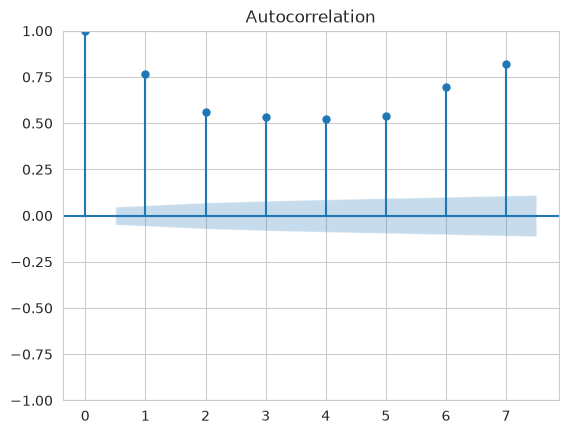

In [713]:
plot_acf(agg_serie, lags=7);

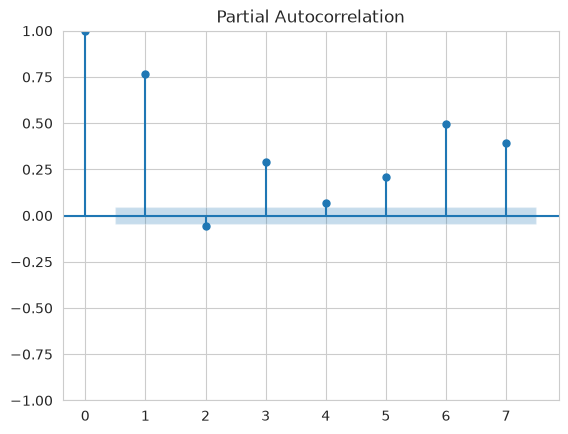

In [714]:
plot_pacf(agg_serie, lags=7);

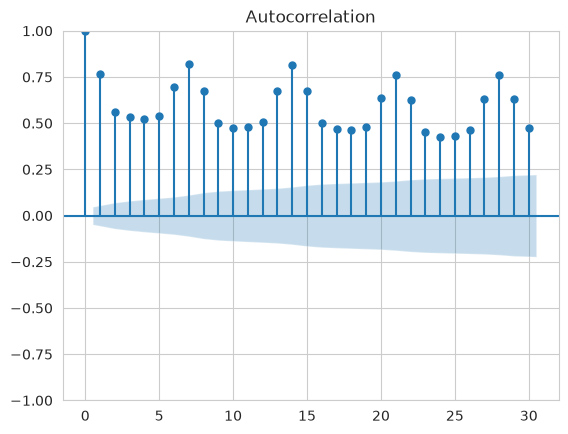

In [715]:
plot_acf(agg_serie, lags=30);

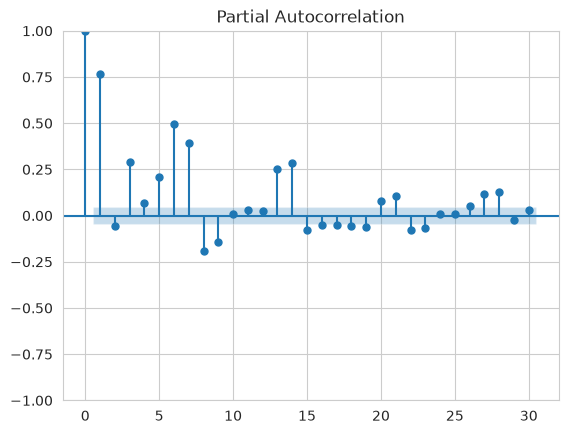

In [716]:
plot_pacf(agg_serie, lags=30);

In [717]:
result = adfuller(agg_serie, regression='ct')

print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[2]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')    

ADF Statistic: -5.685201419705399
n_lags: 22
p-value: 9.813892732481312e-06
Critial Values:
   1%, -3.964230724633873
Critial Values:
   5%, -3.4131365120665933
Critial Values:
   10%, -3.128608080160255


**Conclusions:**

- **ACF (lags=7)**: all bars lie outside the confidence band and do not decay toward zero — a signature of non-stationarity driven by the upward trend. The values at lags 6 and 7 are the highest among lags 1–7, confirming the weekly seasonal cycle: today's sales correlate most strongly with the same day of the previous week.
- **ACF (lags=30)**: peaks repeat at lags 7, 14, 21, 28 — the weekly pattern persists and is detectable up to four weeks back. The slow, non-decaying envelope of the ACF further confirms the presence of a trend.
- **PACF**: after the dominant spike at lag 1 (~0.75), most partial autocorrelations fall inside the confidence band beyond lag ~10. Lags 6 and 7 show notable direct effects even after removing intermediate lags, confirming the weekly seasonality is a direct (not indirect) effect. This suggests an AR(7) or AR(8) structure would capture most of the direct autocorrelation.
- **ADF test** (`regression='ct'`): ADF statistic = −5.69, p-value ≈ 0.000001 — the null hypothesis of a unit root is rejected at the 1% level. The series is **trend-stationary**: it is stationary around its deterministic trend. Using `regression='c'` (no trend) yielded p = 0.09 and failed to reject — demonstrating that modelling the trend is essential for a correct stationarity assessment.
- **Implication for modelling**: the series does not require differencing. Including explicit trend and seasonal features (day of week, week number, month) is sufficient to achieve stationarity in the residuals.